# Waste Classification - Custom CNN

## Setup

### Import Necessary Libraries:

In [6]:
%pip install tensorflow
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [7]:
import kagglehub
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

In [8]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print(tf.config.list_physical_devices())

TensorFlow version: 2.16.2
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Download and explore the dataset

 This dataset has 15,150 images from 12 different classes of household garbage; paper, cardboard, biological, metal, plastic, green-glass, brown-glass, white-glass, clothes, shoes, batteries, and trash.

```garbage_classification/
├── battery/
├── biological/
├── brown-glass/
├── cardboard/
├── clothes/
├── green-glass/
├── metal/
├── paper/
├── plastic/
├── shoes/
├── trash/
└── white-glass/```


In [ ]:
import kagglehub

path = kagglehub.dataset_download(" /garbage-classification")

print("Path to dataset files:", path)

print("Dataset folder:")
print(os.listdir(path))

Path to dataset files: /Users/thazinhtun/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1
Dataset folder:
['garbage_classification']


In [10]:
if "garbage_classification" in os.listdir(path):
    dataset_path = os.path.join(path, "garbage_classification")
else:
    dataset_path = path

print("Final dataset path:", dataset_path)

Final dataset path: /Users/thazinhtun/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1/garbage_classification


### Merge glass classes

In [11]:
import shutil

mapping = {
    'green-glass': 'glass',
    'white-glass': 'glass',
    'brown-glass': 'glass'
}

original_dataset_path = Path(path) / 'garbage_classification'
if not original_dataset_path.exists():
    original_dataset_path = Path(path)

merged_dataset_path = Path('garbage_classification_merged_glass')
merged_dataset_path.mkdir(exist_ok=True)

for class_folder in original_dataset_path.iterdir():
    if class_folder.is_dir():
        class_name = mapping.get(class_folder.name, class_folder.name)
        new_class_folder = merged_dataset_path / class_name
        new_class_folder.mkdir(exist_ok=True)

        for image_file in class_folder.iterdir():
            if image_file.is_file():
                new_image_name = f'{class_folder.name}_{image_file.name}'
                new_image_path = new_class_folder / new_image_name

                if not new_image_path.exists():
                    shutil.copy2(image_file, new_image_path)

dataset_path = str(merged_dataset_path)
print('Using 10-class dataset path:', dataset_path)


Using 10-class dataset path: garbage_classification_merged_glass


In [12]:
classes = os.listdir(dataset_path)

print("garbage_classification Classes:")
for c in classes:
    print("-", c)

garbage_classification Classes:
- paper
- clothes
- metal
- cardboard
- trash
- glass
- biological
- battery
- plastic
- shoes


### Visualize Class Distribution

paper: 1050 images
clothes: 5325 images
metal: 769 images
cardboard: 891 images
trash: 697 images
glass: 2011 images
biological: 985 images
battery: 945 images
plastic: 865 images
shoes: 1977 images


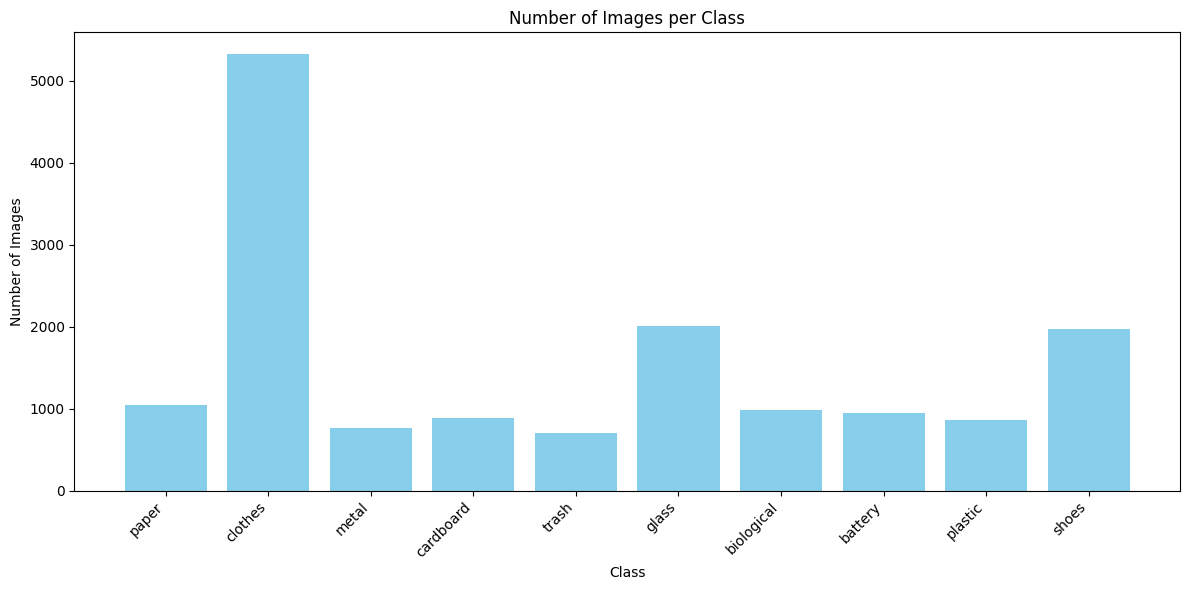

In [13]:
class_counts = {}

for c in classes:
    folder_path = os.path.join(dataset_path, c)

    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        class_counts[c] = count
        print(f"{c}: {count} images")

plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values(), color="skyblue")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Based on the above class distribution, the classes are imbalance mostly clothes class.

## Vasualize Images

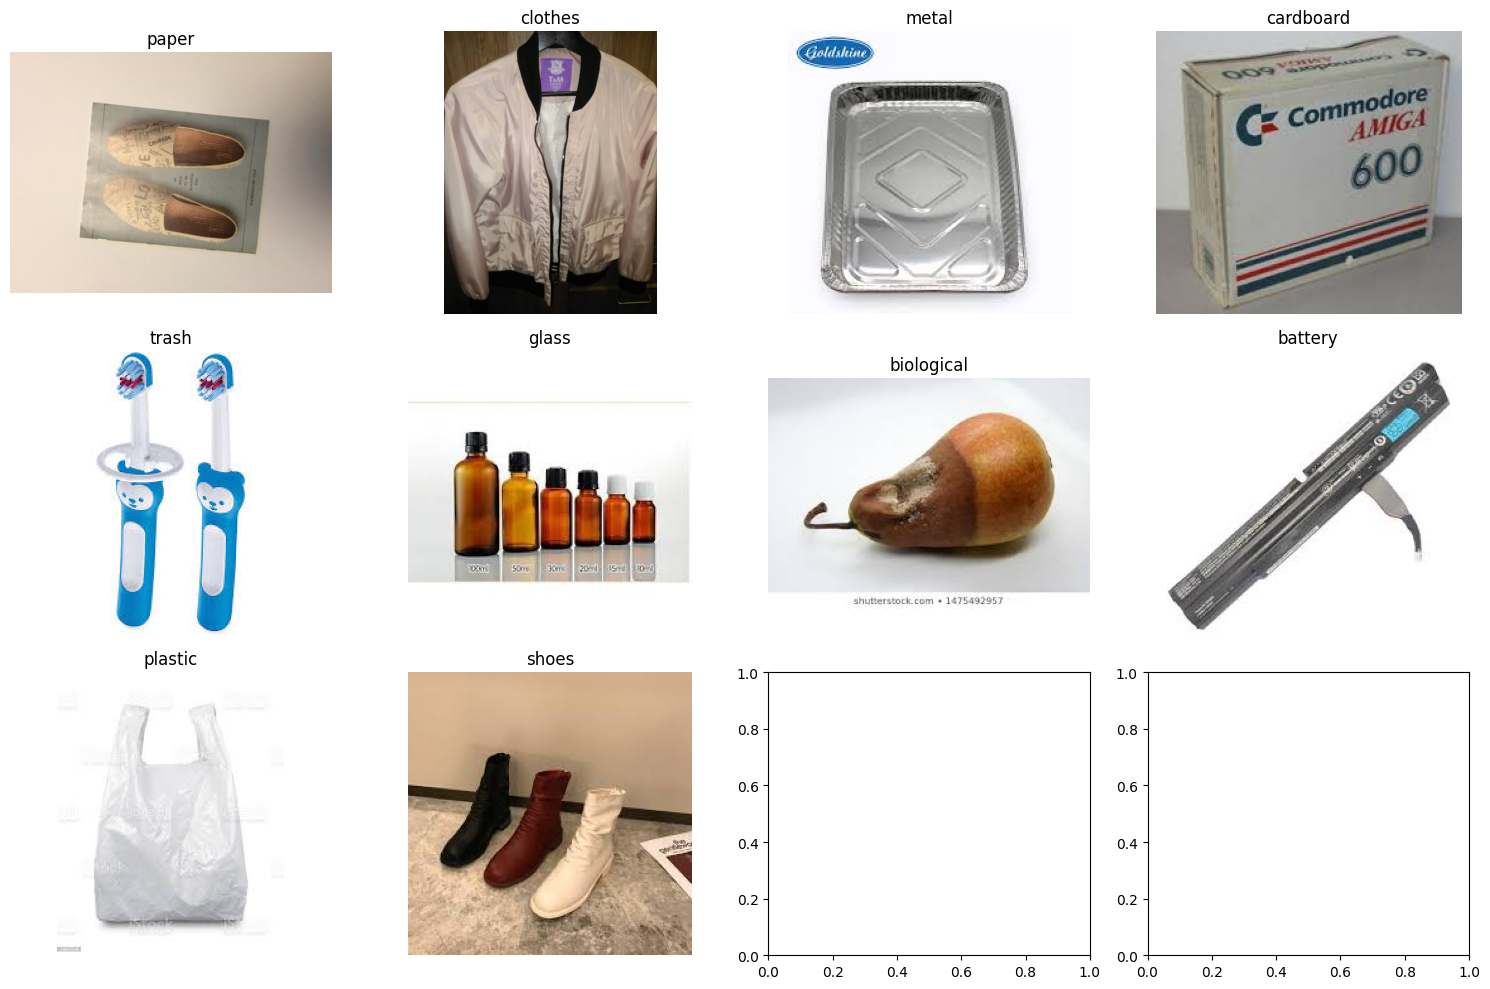

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

classes_path = [p for p in Path(dataset_path).iterdir() if p.is_dir()]

i = 0

for folder in classes_path:

    images = list(folder.glob("*.*"))

    if len(images) == 0:
        continue

    img_path = random.choice(images)
    img = tf.keras.utils.load_img(img_path)

    axes[i].imshow(img)
    axes[i].set_title(folder.name)
    axes[i].axis("off")

    i += 1

plt.tight_layout()
plt.show()

## Create Dataset

### Define some parameters of the loader

In [15]:
batch_size = 32
img_height = 224
img_width = 224

### Use 80% of the images for training and 20% for validation.

In [16]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 15515 files belonging to 10 classes.
Using 12412 files for training.


2026-06-05 21:22:57.208382: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-06-05 21:22:57.208556: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-05 21:22:57.208561: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-06-05 21:22:57.208783: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-05 21:22:57.208796: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 15515 files belonging to 10 classes.
Using 3103 files for validation.


In [17]:
class_names = train_ds.class_names
print(class_names)

['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


### Use Class Weights during training since the dataset is imbalance


In [18]:
total_images = sum(class_counts.values())
num_classes = len(class_names)

class_weight_dict = {}

for i, class_name in enumerate(class_names):
    class_weight_dict[i] = total_images / (num_classes * class_counts[class_name])

print("Class weights:")
print(class_weight_dict)

Class weights:
{0: 1.6417989417989418, 1: 1.5751269035532995, 2: 1.7413019079685745, 3: 0.29136150234741787, 4: 0.7715067130780706, 5: 2.017555266579974, 6: 1.4776190476190476, 7: 1.7936416184971098, 8: 0.7847749114820435, 9: 2.22596843615495}


### Visualize images from Training dataset

2026-06-05 21:22:57.785550: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


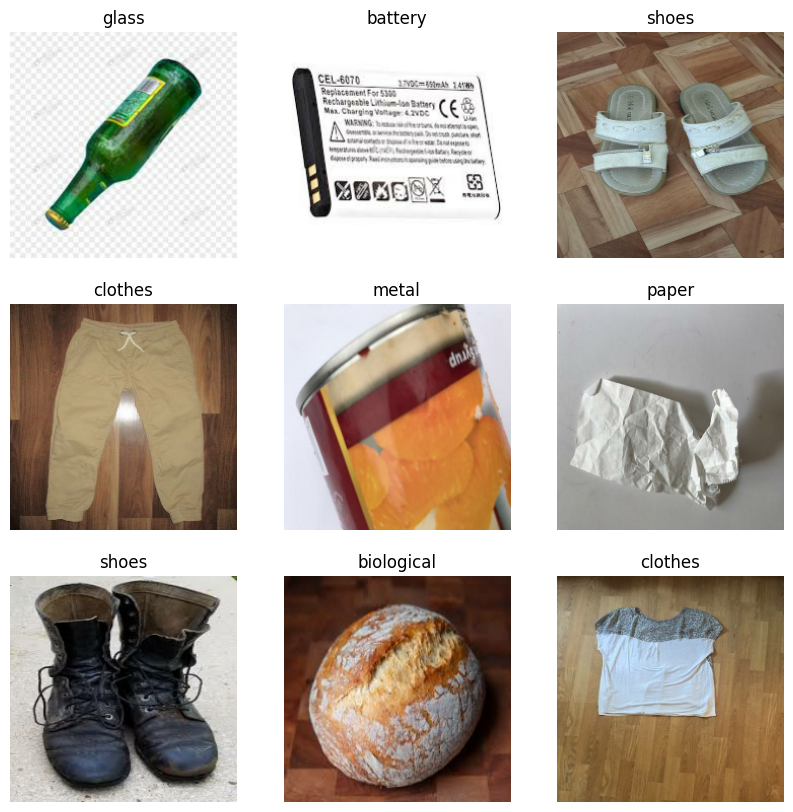

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [20]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


### Configure the dataset for performance

In [21]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

### Standardize the data

In [22]:
import tensorflow as tf
from tensorflow.keras import layers
normalization_layer = layers.Rescaling(1./255)

In [23]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


### Data Augmentation


In [24]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal",input_shape=(img_height,img_width,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

])

/opt/homebrew/Caskroom/miniforge/base/envs/waste-classification/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Early Stopping

In [25]:
import keras


def get_early_stopping_callback(patience=5):

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1,
    )

    return [early_stop, reduce_lr]

### Model 1: Custom CNN

In [26]:
def build_cnn(num_classes):

    model = keras.Sequential([
        layers.Input(shape=(img_height, img_width, 3)),

        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
            
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        
        layers.GlobalAveragePooling2D(),
        
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax', name="outputs")    
        ])
    
    model.summary();

    return model

cnn = build_cnn(num_classes)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,698 (1.75 MB)

 Trainable params: 457,738 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

### Compile Model

In [31]:
def compile_model(model):

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss = 'sparse_categorical_crossentropy' , metrics=['accuracy'])


    return model

### Train Model

In [32]:
def train_model(model, train_ds, val_ds, class_weights=None, epochs=15,patience=5):

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=get_early_stopping_callback(patience=patience),
        class_weight=class_weights
    )

    return history

### Create plots of the loss and accuracy on the training and validation sets:

In [33]:
import matplotlib.pyplot as plt

def plot_history(history, title="Model Performance"):

    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')

    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # ---------------- Accuracy ----------------
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')

    # ---------------- Loss ----------------
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')

    plt.show()

### Train CNN Model

In [34]:
cnn = compile_model(cnn)

cnn_history = train_model(cnn, train_ds, val_ds,None, 20, patience=5)

Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 171s 424ms/step - accuracy: 0.4903 - loss: 1.6921 - val_accuracy: 0.4032 - val_loss: 2.3854 - learning_rate: 0.0010
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 165s 413ms/step - accuracy: 0.5267 - loss: 1.5553 - val_accuracy: 0.5395 - val_loss: 1.8326 - learning_rate: 0.0010
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 162s 401ms/step - accuracy: 0.5582 - loss: 1.3878 - val_accuracy: 0.4525 - val_loss: 2.3693 - learning_rate: 0.0010
Epoch 4/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 163s 405ms/step - accuracy: 0.5931 - loss: 1.2671 - val_accuracy: 0.5827 - val_loss: 1.2916 - learning_rate: 0.0010
Epoch 5/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 163s 400ms/step - accuracy: 0.6019 - loss: 1.2091 - val_accuracy: 0.5456 - val_loss: 1.5108 - learning_rate: 0.0010
Epoch 6/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 160s 397ms/step - accuracy: 0.6227 - loss: 1.1508 - val_accuracy: 0.5901 - val_loss: 1.2564 - learning_rate: 0.0010
Epoch 7/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 160s 396ms/step - accura

### Visualize training results: CNN Model

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])
[0.490251362323761, 0.5266677141189575, 0.5581694841384888, 0.5931356549263, 0.6019175052642822, 0.6227038502693176, 0.6367225050926208, 0.6429262161254883, 0.6594424843788147, 0.7109249234199524, 0.7278439998626709, 0.729697048664093, 0.740251362323761, 0.7448437213897705, 0.7609571218490601, 0.7695778012275696, 0.7722365260124207, 0.7807766795158386, 0.777795672416687, 0.7939896583557129]
[0.4031582474708557, 0.5394779443740845, 0.45246535539627075, 0.5826619267463684, 0.5456010103225708, 0.5900741219520569, 0.6406702995300293, 0.5404447317123413, 0.5124073624610901, 0.658072829246521, 0.7157589197158813, 0.7483080625534058, 0.6174669861793518, 0.6977118849754333, 0.7757009267807007, 0.7782790660858154, 0.7953593134880066, 0.7757009267807007, 0.7911698222160339, 0.791814386844635]


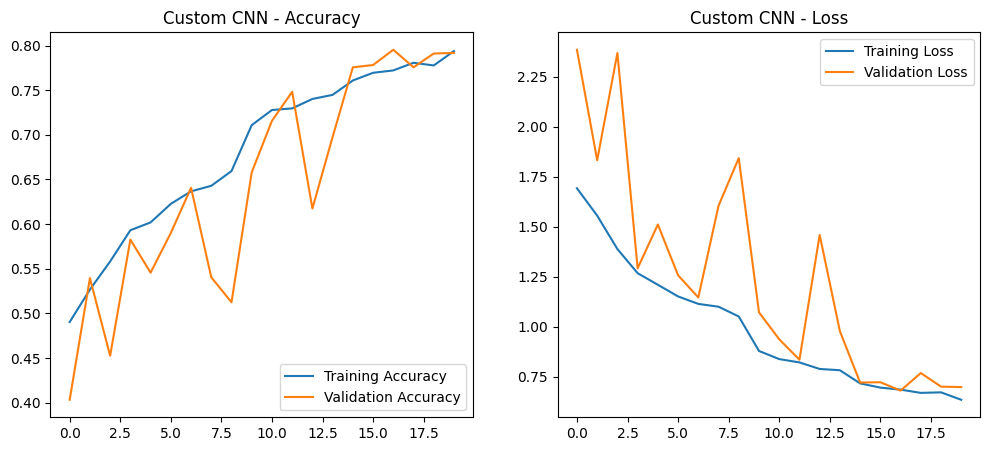

In [35]:
print(cnn_history.history.keys())
print(cnn_history.history['accuracy'])
print(cnn_history.history['val_accuracy'])
plot_history(cnn_history, "Custom CNN")

In [36]:
val_loss, val_acc = cnn.evaluate(val_ds)
print(val_acc)

97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.7954 - loss: 0.6794
0.7953593134880066


In [37]:
import cv2
image_folder = 'assets/test_images/' 
print(class_names)

if os.path.exists(image_folder):
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    for img_name in image_files:
        img_path = os.path.join(image_folder, img_name)
        img_array = cv2.imread(img_path)
        img_array = cv2.resize(img_array, (img_width, img_height))
        
    
        img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
        
        img_array = np.expand_dims(img_array, axis=0) 
        
        predictions = cnn.predict(img_array, verbose=0)
        
        print(f"Image Name: {img_name}")
        print("This image most likely belongs to {} with a {:.2f} percent confidence."
              .format(class_names[np.argmax(predictions)], 100 * np.max(predictions)))
        print("-" * 60)

['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Image Name: test_metal_3.jpeg
This image most likely belongs to glass with a 54.94 percent confidence.
------------------------------------------------------------
Image Name: test_cloth_1.jpeg
This image most likely belongs to clothes with a 38.73 percent confidence.
------------------------------------------------------------
Image Name: test_metal_4.jpg
This image most likely belongs to paper with a 55.77 percent confidence.
------------------------------------------------------------
Image Name: test_plastic_1.jpeg
This image most likely belongs to clothes with a 98.89 percent confidence.
------------------------------------------------------------
Image Name: test_bio_1.jpg
This image most likely belongs to paper with a 97.61 percent confidence.
------------------------------------------------------------
Image Name: test_greenglass_1.jpeg
This image most likely belongs to gla

              precision    recall  f1-score   support

     battery       0.73      0.74      0.73       187
  biological       0.89      0.77      0.82       200
   cardboard       0.89      0.79      0.84       178
     clothes       0.85      0.97      0.91      1084
       glass       0.85      0.72      0.78       402
       metal       0.64      0.53      0.58       148
       paper       0.68      0.82      0.74       217
     plastic       0.59      0.59      0.59       169
       shoes       0.83      0.59      0.69       392
       trash       0.61      0.83      0.70       126

    accuracy                           0.80      3103
   macro avg       0.76      0.74      0.74      3103
weighted avg       0.80      0.80      0.79      3103



2026-06-05 22:36:17.621852: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


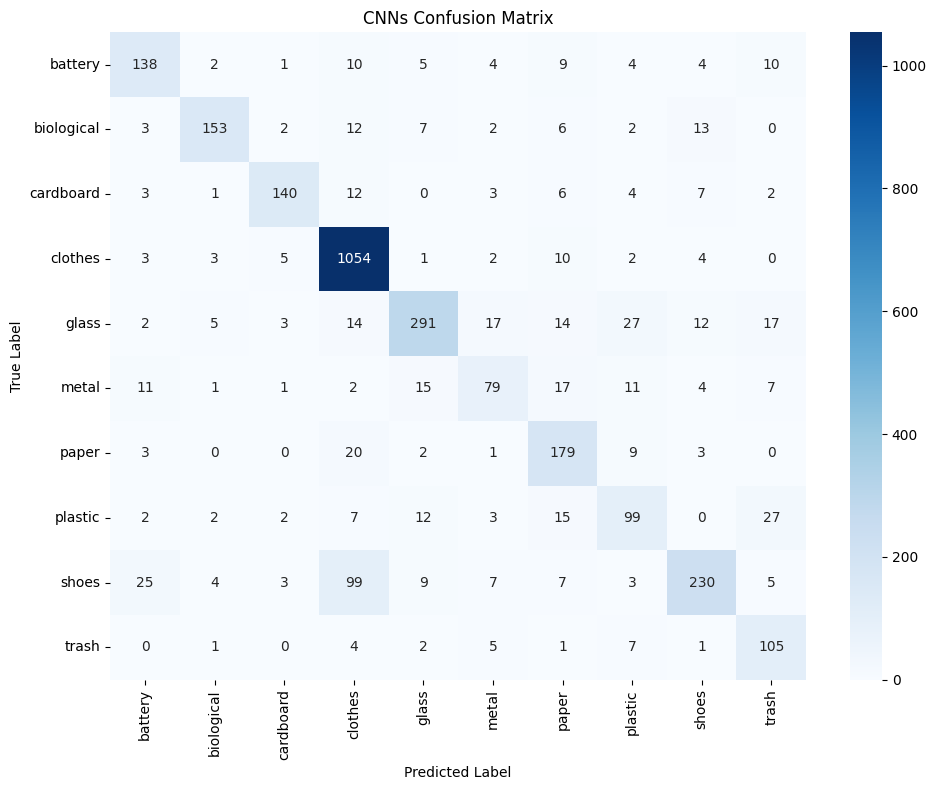

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = cnn.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNNs Confusion Matrix')
plt.tight_layout()
plt.show()
